# MoE-RenalSAM-CG — Notebook 02: Create Train / Val / Test Splits

## Purpose
Split the 8737 Kaggle images into stratified train / val / test sets.

```
8737 images
    ├── Train  70%  → model training  (pseudo-GT added in Notebook 03)
    ├── Val    10%  → validation during training
    └── Test   20%  → final evaluation vs expert masks (LOCKED — never touched during training)
```

**Inputs:**
- `data/raw/kaggle/{Normal,Tumor,Stone}/`
- `data/processed/renseg_masks/{Normal,Tumor,Stone}/`  ← expert masks (test only)

**Outputs:**
- `data/splits/train_manifest.csv`
- `data/splits/val_manifest.csv`
- `data/splits/test_manifest.csv`
- `data/splits/split_summary.json`

## 0. Imports & Setup

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from PIL import Image

warnings.filterwarnings('ignore')

# ── move to project root if needed ───────────────────────────────────────────
if not (Path.cwd() / 'data').exists():
    os.chdir(Path.cwd().parent)
print('Working directory:', Path.cwd())

def header(msg): print(f'\n{"="*65}\n  {msg}\n{"="*65}')
def ok(msg):     print(f'  [ OK ]  {msg}')
def info(msg):   print(f'  [INFO]  {msg}')
def warn(msg):   print(f'  [WARN]  {msg}')
def err(msg):    print(f'  [ERR ]  {msg}')

Working directory: D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG


## 1. Configuration

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
KAGGLE_ROOT  = Path('data/raw/kaggle')
MASKS_ROOT   = Path('data/processed/renseg_masks')
SPLITS_DIR   = Path('data/splits')
REPORTS_DIR  = Path('data/processed/reports')

# ── split ratios ──────────────────────────────────────────────────────────────
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.10
TEST_RATIO   = 0.20
SEED         = 42

CLASSES      = ['Normal', 'Tumor', 'Stone']
IMG_EXTS     = {'.jpg', '.jpeg', '.png'}

# ── create output directories ─────────────────────────────────────────────────
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

header('Configuration')
info(f'Kaggle root  : {KAGGLE_ROOT.resolve()}')
info(f'Masks root   : {MASKS_ROOT.resolve()}')
info(f'Splits dir   : {SPLITS_DIR.resolve()}')
info(f'Split ratios : train={TRAIN_RATIO}  val={VAL_RATIO}  test={TEST_RATIO}')
info(f'Random seed  : {SEED}')

for root, label in [(KAGGLE_ROOT, 'Kaggle'), (MASKS_ROOT, 'RenSeg masks')]:
    if root.exists(): ok(f'{label} root found')
    else:             err(f'{label} root NOT found: {root}')


  Configuration
  [INFO]  Kaggle root  : D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\raw\kaggle
  [INFO]  Masks root   : D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\processed\renseg_masks
  [INFO]  Splits dir   : D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\splits
  [INFO]  Split ratios : train=0.7  val=0.1  test=0.2
  [INFO]  Random seed  : 42
  [ OK ]  Kaggle root found
  [ OK ]  RenSeg masks root found


## 2. Collect All Image Paths

In [3]:
def collect_samples(kaggle_root: Path, masks_root: Path,
                     classes: list) -> pd.DataFrame:
    """
    Collect all image paths from Kaggle.
    For each image, record the expert mask path from renseg_masks.
    Returns a DataFrame with columns:
        image_path, class_name, expert_mask_path, has_expert_mask
    """
    records = []

    for cls in classes:
        img_dir  = kaggle_root / cls
        mask_dir = masks_root  / cls

        if not img_dir.exists():
            warn(f'Image dir not found: {img_dir}')
            continue

        img_files = sorted(
            p for p in img_dir.iterdir()
            if p.suffix.lower() in IMG_EXTS
        )

        for img_path in img_files:
            mask_path = mask_dir / f'{img_path.stem}_mask.png'
            records.append({
                'image_path'      : str(img_path),
                'class_name'      : cls,
                'expert_mask_path': str(mask_path) if mask_path.exists() else '',
                'has_expert_mask' : mask_path.exists(),
                'stem'            : img_path.stem,
            })

    return pd.DataFrame(records)


header('Collecting image paths')
all_df = collect_samples(KAGGLE_ROOT, MASKS_ROOT, CLASSES)

print(f'\n  Total images collected: {len(all_df)}')
print(f'\n  Per-class breakdown:')
for cls in CLASSES:
    sub = all_df[all_df['class_name'] == cls]
    has_mask = sub['has_expert_mask'].sum()
    print(f'    {cls:<10}: {len(sub):>5} images  |  expert masks: {has_mask}')



  Total images collected: 8737

  Per-class breakdown:
    Normal    :  5077 images  |  expert masks: 5077
    Tumor     :  2283 images  |  expert masks: 2283
    Stone     :  1377 images  |  expert masks: 1377


## 3. Stratified Split — Per Class

In [4]:
def stratified_split(df: pd.DataFrame, train_ratio: float,
                      val_ratio: float, seed: int) -> pd.DataFrame:
    """
    Perform stratified split per class.
    Adds 'split' column: 'train' | 'val' | 'test'
    """
    df      = df.copy()
    splits  = []

    for cls in df['class_name'].unique():
        cls_df = df[df['class_name'] == cls].copy()
        n      = len(cls_df)

        # first split: train+val vs test
        trainval_df, test_df = train_test_split(
            cls_df,
            test_size  = 1.0 - train_ratio - val_ratio,
            random_state = seed,
            shuffle    = True
        )

        # second split: train vs val
        # val_ratio relative to total, so recompute for trainval subset
        val_size_relative = val_ratio / (train_ratio + val_ratio)
        train_df, val_df  = train_test_split(
            trainval_df,
            test_size    = val_size_relative,
            random_state = seed,
            shuffle      = True
        )

        train_df = train_df.copy()
        val_df   = val_df.copy()
        test_df  = test_df.copy()

        train_df['split'] = 'train'
        val_df['split']   = 'val'
        test_df['split']  = 'test'

        splits.append(train_df)
        splits.append(val_df)
        splits.append(test_df)

        info(f'{cls:<10}: total={n}  '
             f'train={len(train_df)}  '
             f'val={len(val_df)}  '
             f'test={len(test_df)}')

    return pd.concat(splits, ignore_index=True)


header('Creating stratified splits')
split_df = stratified_split(all_df, TRAIN_RATIO, VAL_RATIO, SEED)

# verify no data leakage
print(f'\n  Total after split: {len(split_df)}')
print(f'  Train: {(split_df.split=="train").sum()}')
print(f'  Val  : {(split_df.split=="val").sum()}')
print(f'  Test : {(split_df.split=="test").sum()}')

# check no image appears in multiple splits
dupes = split_df.groupby('stem')['split'].nunique()
leaks = dupes[dupes > 1]
if len(leaks) == 0:
    ok('Zero data leakage — no image appears in multiple splits.')
else:
    err(f'DATA LEAKAGE DETECTED: {len(leaks)} images in multiple splits!')


  Creating stratified splits
  [INFO]  Normal    : total=5077  train=3553  val=508  test=1016
  [INFO]  Tumor     : total=2283  train=1597  val=229  test=457
  [INFO]  Stone     : total=1377  train=963  val=138  test=276

  Total after split: 8737
  Train: 6113
  Val  : 875
  Test : 1749
  [ OK ]  Zero data leakage — no image appears in multiple splits.


## 4. Verify Split Distribution

In [5]:
header('Split Distribution Verification')

summary_rows = []
print(f'\n  {"Class":<10} {"Split":<8} {"Count":>6} {"% of class":>12}')
print(f'  {"-"*42}')

for cls in CLASSES:
    cls_total = (split_df['class_name'] == cls).sum()
    for spl in ['train', 'val', 'test']:
        count = ((split_df['class_name'] == cls) & (split_df['split'] == spl)).sum()
        pct   = count / cls_total * 100
        print(f'  {cls:<10} {spl:<8} {count:>6} {pct:>11.1f}%')
        summary_rows.append({'class': cls, 'split': spl,
                              'count': count, 'pct': round(pct, 1)})
    print(f'  {"":<10} {"total":<8} {cls_total:>6}')
    print()

# overall
for spl in ['train', 'val', 'test']:
    total = (split_df['split'] == spl).sum()
    pct   = total / len(split_df) * 100
    print(f'  {"ALL":<10} {spl:<8} {total:>6} {pct:>11.1f}%')

summary_df = pd.DataFrame(summary_rows)


  Split Distribution Verification

  Class      Split     Count   % of class
  ------------------------------------------
  Normal     train      3553        70.0%
  Normal     val         508        10.0%
  Normal     test       1016        20.0%
             total      5077

  Tumor      train      1597        70.0%
  Tumor      val         229        10.0%
  Tumor      test        457        20.0%
             total      2283

  Stone      train       963        69.9%
  Stone      val         138        10.0%
  Stone      test        276        20.0%
             total      1377

  ALL        train      6113        70.0%
  ALL        val         875        10.0%
  ALL        test       1749        20.0%


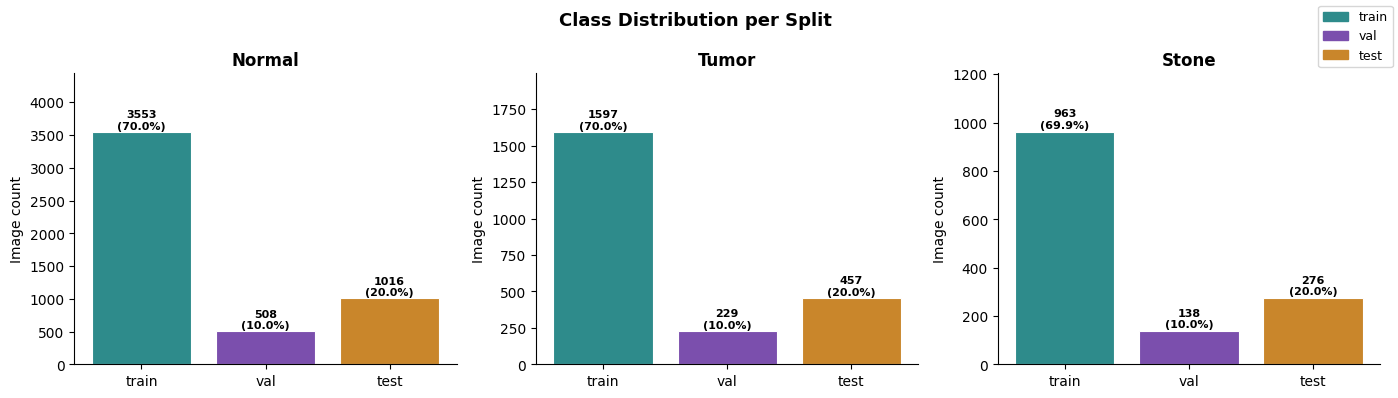

  [ OK ]  Saved: data/processed/reports/split_distribution.png


In [6]:
# ── distribution bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Class Distribution per Split', fontsize=13, fontweight='bold')

colors = {'train': '#2E8B8B', 'val': '#7B4FAD', 'test': '#C9862B'}

for ax, cls in zip(axes, CLASSES):
    sub    = summary_df[summary_df['class'] == cls]
    splits = sub['split'].tolist()
    counts = sub['count'].tolist()
    bars   = ax.bar(splits, counts,
                    color=[colors[s] for s in splits],
                    edgecolor='white', linewidth=0.8)
    ax.set_title(f'{cls}', fontweight='bold')
    ax.set_ylabel('Image count')
    ax.spines[['top', 'right']].set_visible(False)
    for bar, cnt, pct in zip(bars, counts, sub['pct']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{cnt}\n({pct}%)',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_ylim(0, max(counts) * 1.25)

patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
fig.legend(handles=patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
ok('Saved: data/processed/reports/split_distribution.png')

## 5. Save Manifests

In [7]:
header('Saving split manifests')

# ── train manifest ────────────────────────────────────────────────────────────
# columns: image_path, class_name, stem
# pseudo_gt_path and box_path will be added in Notebooks 03 and 04
train_df = split_df[split_df['split'] == 'train'][[
    'image_path', 'class_name', 'stem'
]].reset_index(drop=True)

train_df.to_csv(SPLITS_DIR / 'train_manifest.csv', index=False)
ok(f'train_manifest.csv saved — {len(train_df)} images')

# ── val manifest ──────────────────────────────────────────────────────────────
val_df = split_df[split_df['split'] == 'val'][[
    'image_path', 'class_name', 'stem'
]].reset_index(drop=True)

val_df.to_csv(SPLITS_DIR / 'val_manifest.csv', index=False)
ok(f'val_manifest.csv   saved — {len(val_df)} images')

# ── test manifest ─────────────────────────────────────────────────────────────
# test manifest includes expert_mask_path — this is the evaluation ground truth
test_df = split_df[split_df['split'] == 'test'][[
    'image_path', 'class_name', 'stem', 'expert_mask_path', 'has_expert_mask'
]].reset_index(drop=True)

test_df.to_csv(SPLITS_DIR / 'test_manifest.csv', index=False)
ok(f'test_manifest.csv  saved — {len(test_df)} images')

# ── expert mask coverage in test set ─────────────────────────────────────────
print()
print('  Expert mask coverage in test set:')
for cls in CLASSES:
    sub  = test_df[test_df['class_name'] == cls]
    has  = sub['has_expert_mask'].sum()
    total = len(sub)
    print(f'    {cls:<10}: {has}/{total} have expert masks')


  Saving split manifests
  [ OK ]  train_manifest.csv saved — 6113 images
  [ OK ]  val_manifest.csv   saved — 875 images
  [ OK ]  test_manifest.csv  saved — 1749 images

  Expert mask coverage in test set:
    Normal    : 1016/1016 have expert masks
    Tumor     : 457/457 have expert masks
    Stone     : 276/276 have expert masks


## 6. Sample Image Preview per Split

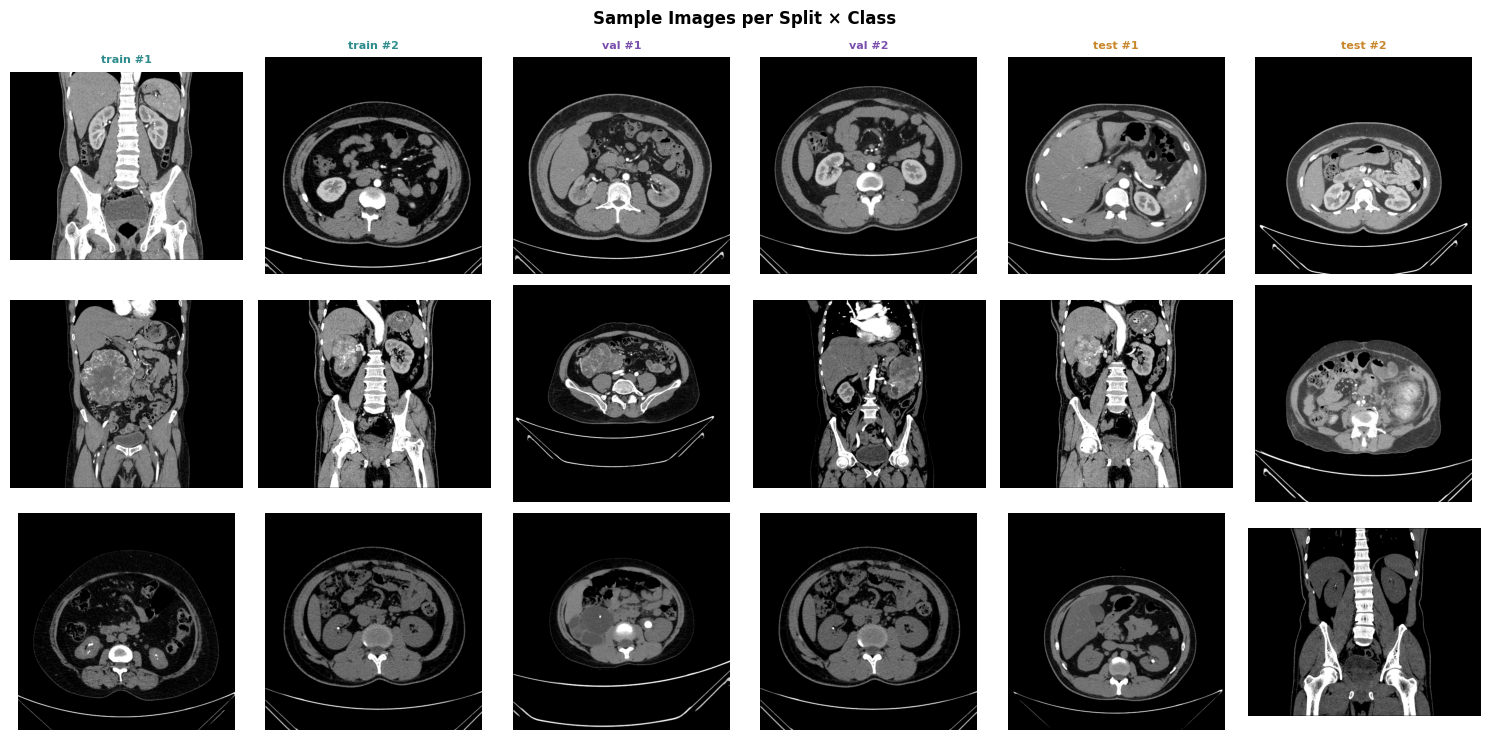

In [8]:
def show_split_samples(split_df: pd.DataFrame, n_per_split: int = 2,
                        seed: int = 42):
    """
    Show sample images from each split × class combination.
    Confirms images loaded correctly after splitting.
    """
    rng    = np.random.default_rng(seed)
    splits = ['train', 'val', 'test']

    fig, axes = plt.subplots(
        len(CLASSES), len(splits) * n_per_split,
        figsize=(len(splits) * n_per_split * 2.5, len(CLASSES) * 2.5)
    )
    fig.suptitle('Sample Images per Split × Class', fontsize=12, fontweight='bold')

    col_titles = []
    for spl in splits:
        for i in range(n_per_split):
            col_titles.append(f'{spl} #{i+1}')

    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=8, fontweight='bold',
                                color=colors.get(title.split()[0], 'black'))

    for row, cls in enumerate(CLASSES):
        col = 0
        for spl in splits:
            sub   = split_df[
                (split_df['class_name'] == cls) &
                (split_df['split'] == spl)
            ]
            picks = rng.choice(len(sub),
                                size=min(n_per_split, len(sub)),
                                replace=False)
            for idx in picks:
                img_path = sub.iloc[idx]['image_path']
                try:
                    img = np.array(Image.open(img_path).convert('RGB'))
                    axes[row, col].imshow(img)
                except Exception:
                    axes[row, col].text(0.5, 0.5, 'load\nerror',
                                        ha='center', va='center',
                                        transform=axes[row, col].transAxes)
                axes[row, col].axis('off')
                if col == 0:
                    axes[row, col].set_ylabel(cls, fontsize=9, fontweight='bold')
                col += 1

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'split_samples.png', dpi=120, bbox_inches='tight')
    plt.show()


show_split_samples(split_df, n_per_split=2)

## 7. Test Set — Expert Mask Coverage Check


  Test Set Expert Mask Verification


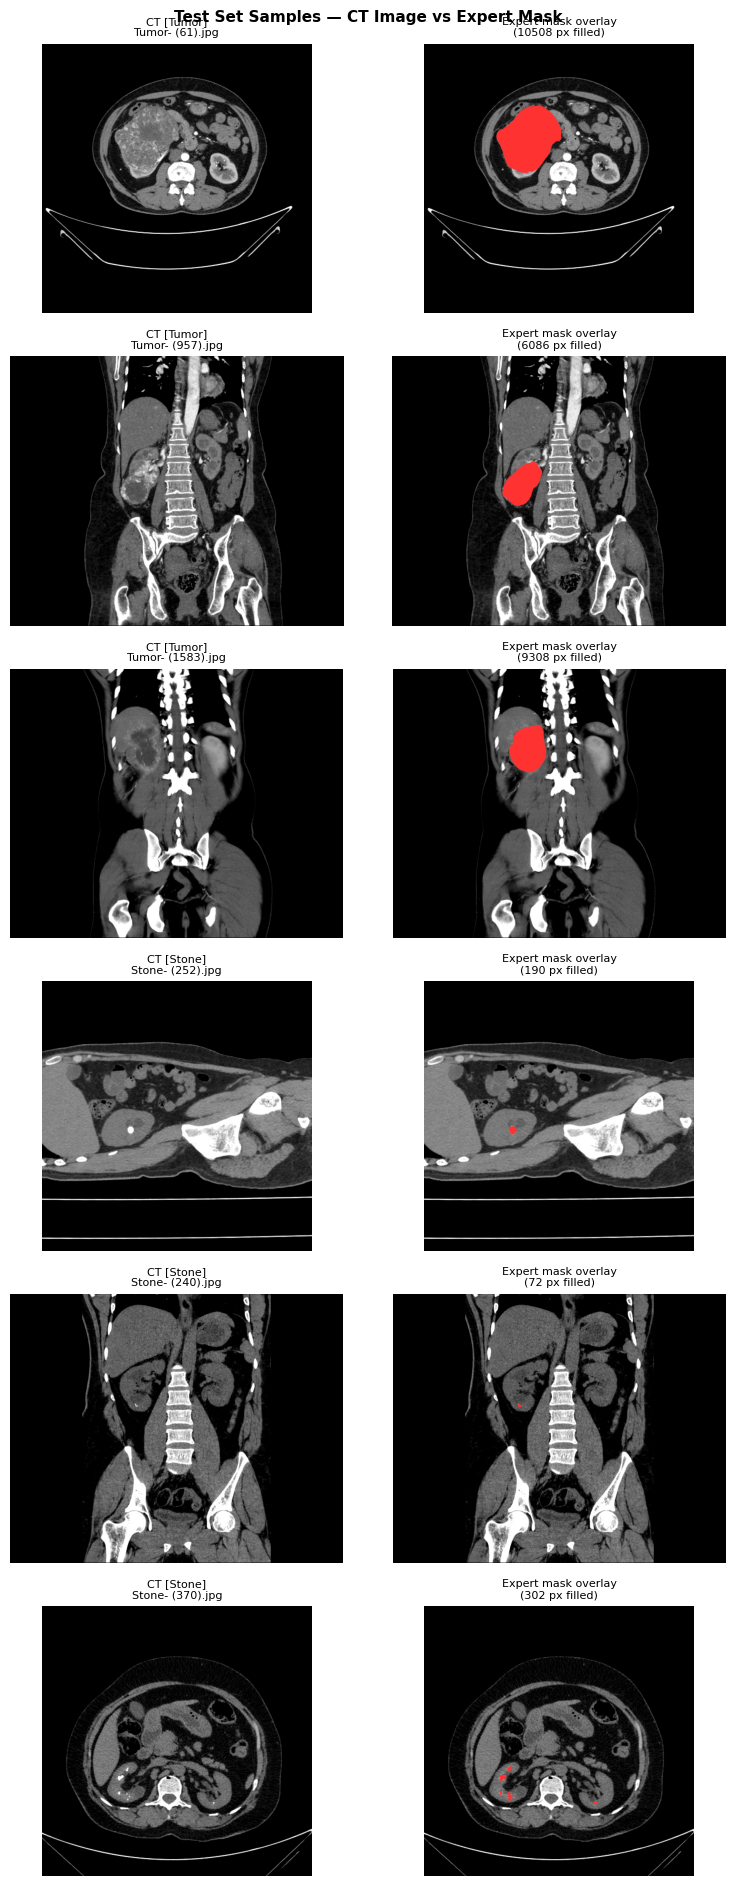

  [ OK ]  Test set samples verified.


In [9]:
header('Test Set Expert Mask Verification')

# show a few test samples with their expert masks
test_tumor = test_df[
    (test_df['class_name'] == 'Tumor') &
    (test_df['has_expert_mask'] == True)
].head(3)

test_stone = test_df[
    (test_df['class_name'] == 'Stone') &
    (test_df['has_expert_mask'] == True)
].head(3)

sample_test = pd.concat([test_tumor, test_stone], ignore_index=True)

if len(sample_test) == 0:
    warn('No annotated test samples found to preview.')
else:
    fig, axes = plt.subplots(len(sample_test), 2,
                              figsize=(8, len(sample_test) * 3.2))
    if len(sample_test) == 1:
        axes = axes[np.newaxis, :]

    fig.suptitle('Test Set Samples — CT Image vs Expert Mask',
                 fontsize=11, fontweight='bold')

    for row, (_, rec) in enumerate(sample_test.iterrows()):
        img  = np.array(Image.open(rec['image_path']).convert('RGB'))
        mask = np.array(Image.open(rec['expert_mask_path']).convert('L'))

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(
            f"CT [{rec['class_name']}]\n{Path(rec['image_path']).name}",
            fontsize=8)
        axes[row, 0].axis('off')

        # overlay mask on CT
        overlay = img.copy()
        if (mask > 0).sum() > 0:
            overlay[mask > 0] = [255, 50, 50]
        axes[row, 1].imshow(overlay)
        axes[row, 1].set_title(
            f'Expert mask overlay\n({(mask>0).sum()} px filled)',
            fontsize=8)
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'test_set_preview.png', dpi=130, bbox_inches='tight')
    plt.show()
    ok('Test set samples verified.')

## 8. Final Summary Report


  Final Summary
  [ OK ]  Saved: data/splits/split_summary.json


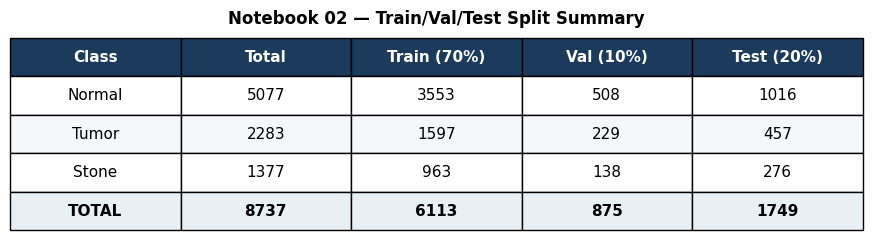


  [ OK ]  Notebook 02 complete.
  [INFO]  Manifests saved to: data/splits/
  [INFO]  Next → Notebook 03: SAM2 Pseudo-GT generation on TRAIN images only


In [10]:
header('Final Summary')

# build per-class per-split counts
counts = {}
for cls in CLASSES:
    counts[cls] = {}
    for spl in ['train', 'val', 'test']:
        counts[cls][spl] = int(
            ((split_df['class_name'] == cls) &
             (split_df['split'] == spl)).sum()
        )

report = {
    'notebook'   : '02_create_splits',
    'total'      : len(split_df),
    'seed'       : SEED,
    'ratios'     : {'train': TRAIN_RATIO, 'val': VAL_RATIO, 'test': TEST_RATIO},
    'counts'     : counts,
    'totals'     : {
        'train': int((split_df['split'] == 'train').sum()),
        'val'  : int((split_df['split'] == 'val').sum()),
        'test' : int((split_df['split'] == 'test').sum()),
    },
    'manifests'  : [
        str(SPLITS_DIR / 'train_manifest.csv'),
        str(SPLITS_DIR / 'val_manifest.csv'),
        str(SPLITS_DIR / 'test_manifest.csv'),
    ]
}

with open(SPLITS_DIR / 'split_summary.json', 'w') as f:
    json.dump(report, f, indent=2)
ok('Saved: data/splits/split_summary.json')

# ── summary table ─────────────────────────────────────────────────────────────
col_labels = ['Class', 'Total', 'Train (70%)', 'Val (10%)', 'Test (20%)']
rows = []
for cls in CLASSES:
    total = sum(counts[cls].values())
    rows.append([
        cls,
        total,
        counts[cls]['train'],
        counts[cls]['val'],
        counts[cls]['test'],
    ])
rows.append([
    'TOTAL',
    sum(r[1] for r in rows),
    sum(r[2] for r in rows),
    sum(r[3] for r in rows),
    sum(r[4] for r in rows),
])

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis('off')
tbl = ax.table(cellText=rows, colLabels=col_labels,
               cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
for col in range(len(col_labels)):
    tbl[0, col].set_facecolor('#1B3A5C')
    tbl[0, col].set_text_props(color='white', fontweight='bold')
for col in range(len(col_labels)):
    tbl[len(rows), col].set_facecolor('#E8F0F5')
    tbl[len(rows), col].set_text_props(fontweight='bold')
for row in range(1, len(rows)):
    bg = '#F5F7FA' if row % 2 == 0 else 'white'
    for col in range(len(col_labels)):
        tbl[row, col].set_facecolor(bg)

plt.title('Notebook 02 — Train/Val/Test Split Summary',
          fontweight='bold', fontsize=12, pad=10)
plt.savefig(REPORTS_DIR / 'split_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

print()
ok('Notebook 02 complete.')
info('Manifests saved to: data/splits/')
info('Next → Notebook 03: SAM2 Pseudo-GT generation on TRAIN images only')